# ArgosQC WildlifeComputers Project Config


1. Connect to WildlifeComputers portal (requires access_key and secret_key pair)
2. Show a list of collaborator (tag owner) who shared projects with OTN.
3. Show/download selected raw tag data from WC portal. 
4. Map tag locations for observation.
5. Generate configuration files for ArgosQC.wc_qc().

In [ ]:
from py_nrt import argos_wc_project_config as awpc
import itables

## 1. Connects to WildlifeComputers portal

### OTN data team for `access_key` (Access Key) and `secret_key` (Secret Key) for OTNDC account.

In [ ]:
# Mandatory input
program = 'irap'

# Ask OTN DC for the keys.
access_key = ""
secret_key = ""

# (Optional) leave it blank if project is not in OTN node.
otn_collection_code = ''

# Destination folder for wc_qc config files and tag downloads.
qc_input_path = r'input'

# Destination folder for wc_qc results: {qc_output_path}/{program}/{collaborator}_{common_name}
qc_output_path = 'qc'

# Set to True to see API payload and response.
verbose=False

## 2. Show a list of collaborator (tag owner) who shared projects with OTN

### Contact OTN data team if your collaborator is not in the list.

In [ ]:
# Get all collaborators
collaborators_df, collaborator_id_widget = awpc.wc_get_collab_ids(a_key=access_key, s_key=secret_key, verbose=verbose)

## 3. Show/download selected raw tag data from WC portal

### The goal of this cell is to identify a list of WC `tag_uuid`s in an OTN project:

#### 3.1 Find the project and WC tags in `otn_satellite_tags` table in OTN Node DB e.g.  

#### 3.2 Column mapping between  `otn_satellite_tags` table and tag information from WC portal.

`collectornumber` - `serial_number`

`ptt_code` - `ptt`

`instrumentmodel` - `tag_type`

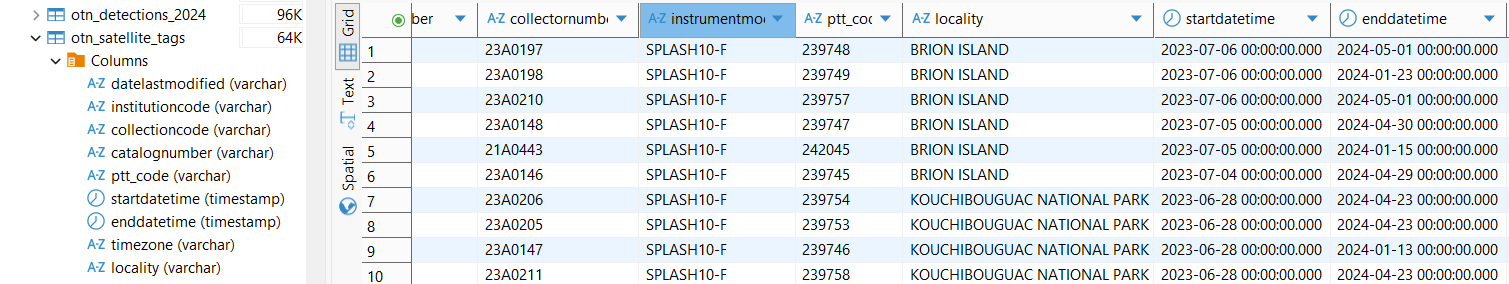

### 3.3 Take note of the list of WC `tag_uuid`s 

In [ ]:
if collaborator_id_widget.value:
    deployment_df = awpc.get_deployments_for_owner_id(
        a_key=access_key, 
        s_key=secret_key, 
        collaborator=collaborator_id_widget.value, 
        verbose=verbose
    )
else:
    print('Please select a collaborator...')

### 3.4 (Optional) Download Selected Tag for Observation
### Note: ptt is reusable; tag UUID is the uinque identifier

In [ ]:
awpc.download_tag(
    a_key=access_key, 
    s_key=secret_key, 
    deployment_df=deployment_df, 
    verbose=verbose
)

## 4. Visualize the Latest Location for Each Tag
4.1 Click the `CSV` button 

4.2 Find downloaded `<collaborator>_latest_<yyyymmdd>.csv`

4.3 Go to kepler.gl instance
https://kepler.gl/demo

4.4 Upload the `<cid>_tracks_<yyyymmdd>.csv`

4.5 Click `Add Layer`

4.6 Select `Basic` select `Point` 

4.7 Under `Color based on` select `tag_uuid`

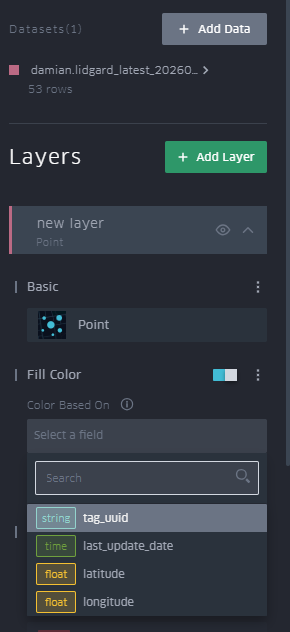

4.8 In Filters tab, click `Add Filter` select `date_time`

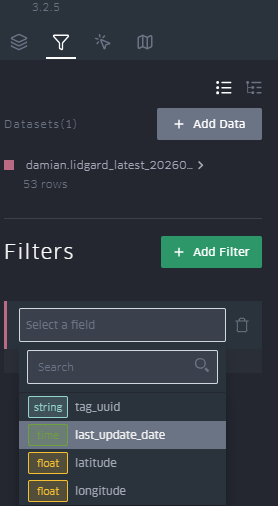

4.9 Adjust rolling window and click the play button

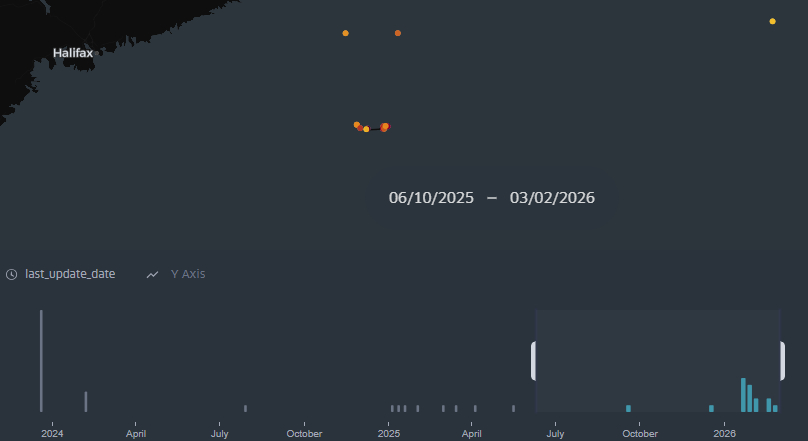

In [ ]:
awpc.export_for_kepler(collaborator=collaborator_id_widget.value, deployment_df=deployment_df)

## 5. Generate WC_QC Configuration Files

#### `time_step` (hours): adjust value (usually between 1 to 10) according to tagged animal's species.
#### `collection_code`: if project is found in OTN. Otherwise leave it blank.
#### `common_name` and `species` (scientific name): source 


In [ ]:
# Default settings
time_step = 3

# Project specific settings
collection_code = 'vmlppws'
common_name = 'grey seal'
species = 'Halichoerus grypus'
release_site = 'BRION ISLAND'
state_country = 'Canada'

tag_uuid_list = ['5f90d1ad17e84815885608c1', '60085a1517e84815e4b95f34']

awpc.create_wc_qc_config(
    program = program,
    collaborator=collaborator_id_widget.value,
    tag_uuid_list=tag_uuid_list,
    otn_collection_code=otn_collection_code,
    qc_input_path=qc_input_path,
    qc_output_path=qc_output_path,
    a_key=access_key, 
    s_key=secret_key, 
    timeout=180,
    time_step=time_step,
    common_name=common_name,
    species=species,
    release_site=release_site,
    state_country=state_country,
    verbose=verbose
)


### Next Step: Launch  `ArgosQC_WildlifeComputers` R-Notebook

- Replace config = "<wc_qc_config_file.json>" with the above output path for `wc_qc config file`
```
library(ArgosQC)
library(pathroutr)
smru_qc(
  wd = ".",
  config = "<wc_qc_config_file.json>"
)
```